## 1. Import Library

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (14, 5)

## 2. Load Data Produsen

In [2]:
data_produsen = pd.read_csv('../data/raw/produsen/data_produsen.csv', parse_dates=['tanggal'])
data_produsen.head()

,tanggal,komoditas,titik_pantau,kabupaten,satuan,harga_kemarin,harga
0,2020-01-01,Beras,PS Bendul Mrisi,Kota Surabaya,kg,10200,10000
1,2020-01-01,Daging Sapi,RPH Pegirikan,Kota Surabaya,kg,91000,90000
2,2020-01-05,Beras,PS Bendul Mrisi,Kota Surabaya,kg,10000,10200
3,2020-01-05,Daging Sapi,RPH Pegirikan,Kota Surabaya,kg,90000,90000
4,2020-01-02,Beras,PS Bendul Mrisi,Kota Surabaya,kg,10000,10000


In [3]:
data_produsen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4872 entries, 0 to 4871
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   tanggal        4872 non-null   datetime64[ns]
 1   komoditas      4872 non-null   object        
 2   titik_pantau   4872 non-null   object        
 3   kabupaten      4872 non-null   object        
 4   satuan         4872 non-null   object        
 5   harga_kemarin  4872 non-null   int64         
 6   harga          4872 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 266.6+ KB


In [4]:
print(data_produsen['komoditas'].value_counts())
print()
print(data_produsen['titik_pantau'].value_counts())

komoditas
Beras          2436
Daging Sapi    2436
Name: count, dtype: int64

titik_pantau
PS Bendul Mrisi    2436
RPH Pegirikan      2436
Name: count, dtype: int64


## 3. Missing Value (harga = 0)

In [5]:
data_produsen['missing'] = data_produsen['harga'] == 0

print(f"Total baris harga=0 : {data_produsen['missing'].sum()} ({data_produsen['missing'].mean()*100:.1f}%)")
print(f"Total NaN sesungguhnya: {data_produsen['harga'].isna().sum()}")

Total baris harga=0 : 653 (13.4%)
Total NaN sesungguhnya: 0


In [6]:
missing_tahun = (data_produsen.groupby([data_produsen['tanggal'].dt.year, 'komoditas'])['missing']
                 .mean().mul(100).round(1).unstack())
missing_tahun

komoditas,Beras,Daging Sapi
tanggal,,
2020,13.7,14.5
2021,5.5,8.2
2022,1.4,1.4
2023,0.3,0.3
2024,0.0,0.0
2025,0.0,0.3
2026,99.6,100.0


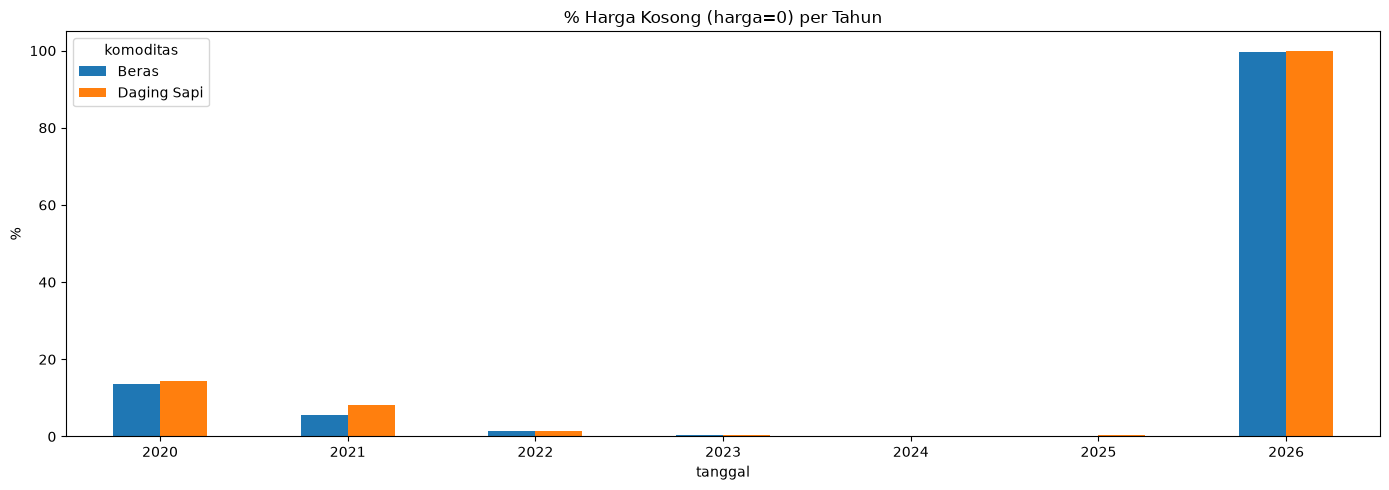

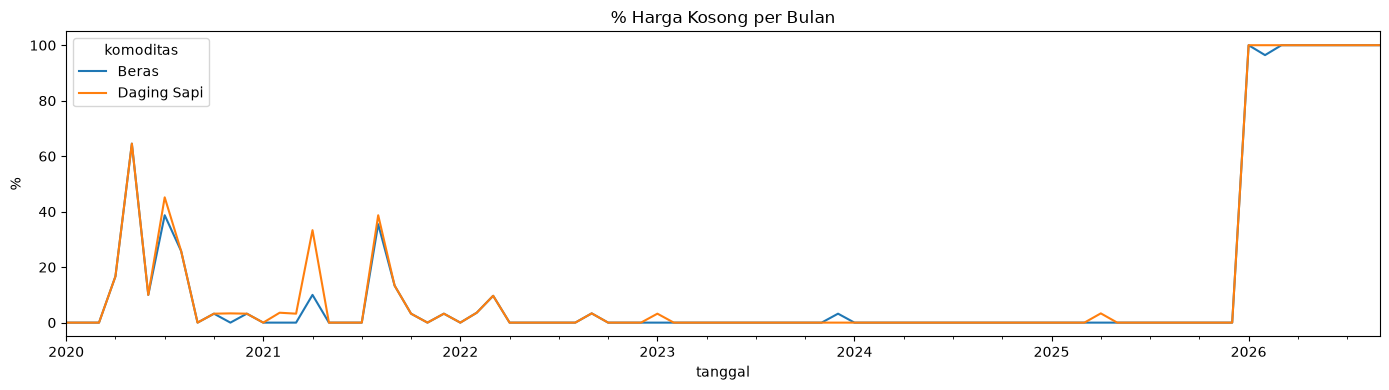

In [7]:
missing_tahun.plot(kind='bar', title='% Harga Kosong (harga=0) per Tahun')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# line chart: kelengkapan data per bulan (terlihat jelas kapan pelaporan berhenti)
bulanan_missing = (data_produsen.set_index('tanggal').groupby('komoditas')['missing']
                   .resample('MS').mean().mul(100).unstack(level=0))
bulanan_missing.plot(figsize=(14, 4), title='% Harga Kosong per Bulan')
plt.ylabel('%')
plt.legend(title='komoditas')
plt.tight_layout()
plt.show()

## 4. Cek Tanggal Bolong & Gap Terpanjang

In [8]:
for k, g in data_produsen.groupby('komoditas'):
    full = pd.date_range(g['tanggal'].min(), g['tanggal'].max(), freq='D')
    bolong = len(full) - g['tanggal'].nunique()
    print(f"{k}: {g['tanggal'].min().date()} -> {g['tanggal'].max().date()} | hari bolong: {bolong}/{len(full)}")

Beras: 2020-01-01 -> 2026-09-01 | hari bolong: 0/2436
Daging Sapi: 2020-01-01 -> 2026-09-01 | hari bolong: 0/2436


In [9]:
for k, g in data_produsen.groupby('komoditas'):
    g = g.sort_values('tanggal')
    run = max_run = 0
    for h in (g['harga'] == 0):
        run = run + 1 if h else 0
        max_run = max(max_run, run)
    print(f"{k}: gap terpanjang {max_run} hari")

Beras: gap terpanjang 197 hari
Daging Sapi: gap terpanjang 244 hari


In [10]:
# kapan harga valid terakhir & di mana gap besar terjadi
for k, g in data_produsen.groupby('komoditas'):
    g = g.sort_values('tanggal')
    valid = g[g['harga'] > 0].copy()
    print(k)
    print('  harga valid terakhir :', valid['tanggal'].max().date())
    valid['selisih'] = valid['tanggal'].diff().dt.days
    for _, r in valid[valid['selisih'] > 14].iterrows():
        print(f"  gap besar: {int(r['selisih'])} hari kosong, terisi lagi mulai {r['tanggal'].date()}")

Beras
  harga valid terakhir : 2026-02-16
  gap besar: 22 hari kosong, terisi lagi mulai 2020-06-02
  gap besar: 21 hari kosong, terisi lagi mulai 2020-08-09
  gap besar: 47 hari kosong, terisi lagi mulai 2026-02-16
Daging Sapi
  harga valid terakhir : 2025-12-31
  gap besar: 22 hari kosong, terisi lagi mulai 2020-06-02
  gap besar: 21 hari kosong, terisi lagi mulai 2020-08-09


## 5. Tren Harga Produsen

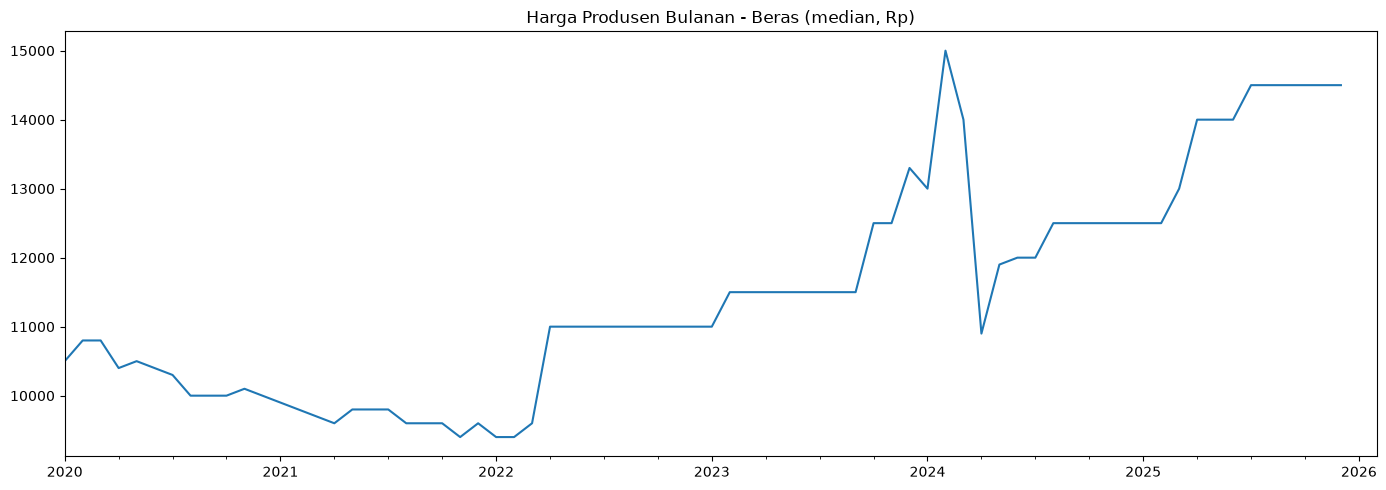

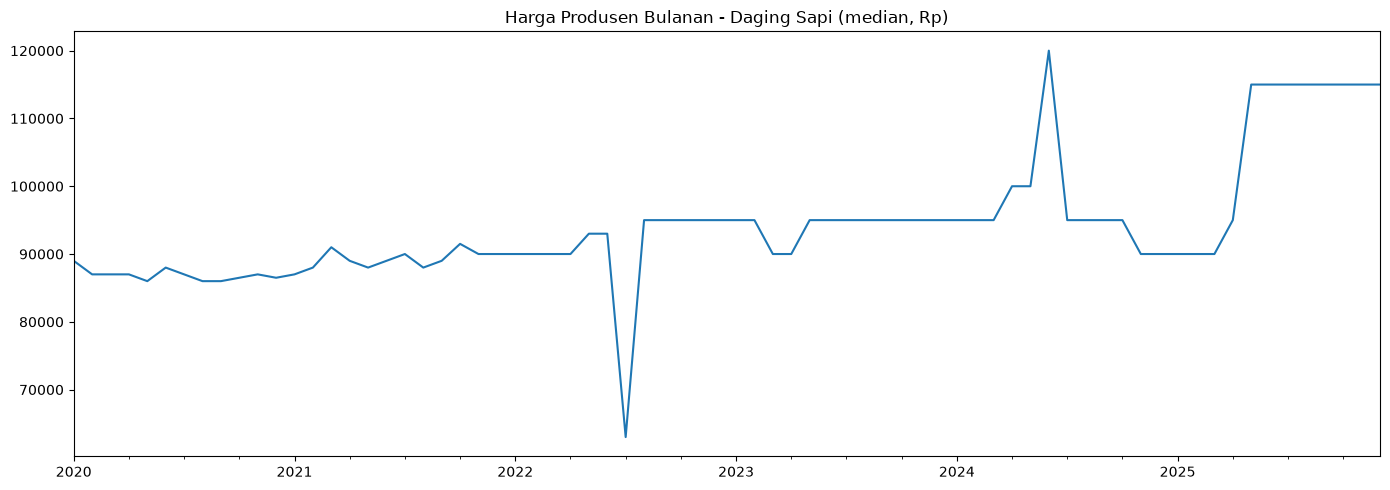

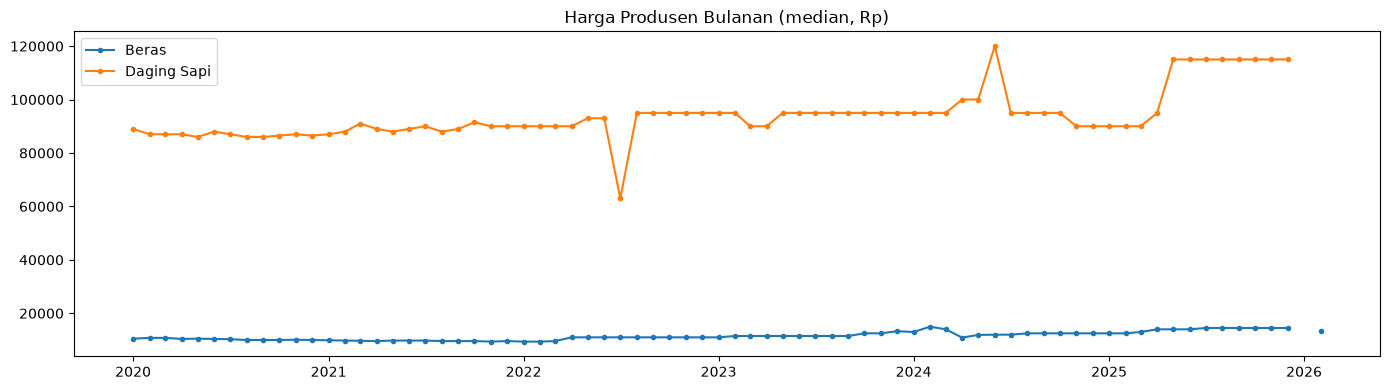

In [11]:
for k, g in data_produsen[data_produsen['harga'] > 0].groupby('komoditas'):
    bulanan = g.set_index('tanggal')['harga'].resample('MS').median()
    bulanan.plot(title=f'Harga Produsen Bulanan - {k} (median, Rp)')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()

# gabungan: tren beras produsen vs harian bulanan (langsung terlihat trend & gap)
fig, ax = plt.subplots(figsize=(14, 4))
for k, g in data_produsen[data_produsen['harga'] > 0].groupby('komoditas'):
    bulanan = g.set_index('tanggal')['harga'].resample('MS').median()
    ax.plot(bulanan.index, bulanan.values, marker='o', markersize=3, label=k)
ax.set_title('Harga Produsen Bulanan (median, Rp)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Distribusi Harga

In [12]:
stat = (data_produsen[data_produsen['harga'] > 0]
        .groupby('komoditas')['harga']
        .agg(median='median', mean='mean', std='std', min='min', max='max')
        .round(0))
stat

,median,mean,std,min,max
komoditas,,,,,
Beras,11000.0,11556.0,1618.0,8700,15000
Daging Sapi,93000.0,94430.0,9097.0,63000,120000


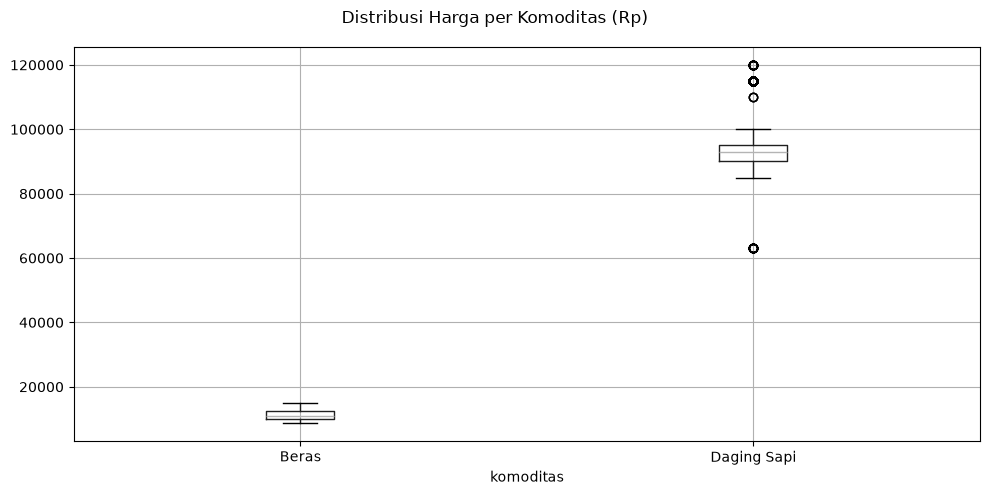

In [13]:
data_produsen[data_produsen['harga'] > 0].boxplot(column='harga', by='komoditas', figsize=(10, 5))
plt.title('')
plt.suptitle('Distribusi Harga per Komoditas (Rp)')
plt.tight_layout()
plt.show()

## 7. Ringkasan Temuan

1. Missing tersamar sebagai 0, total ~13%, tapi 2020-2025 sehat (0-14%, makin ke sini makin bagus).
2. Pelaporan produsen berhenti: Beras valid terakhir 2026-02-16, Daging Sapi 2025-12-31 - sisanya baris harga=0 sampai Sep 2026 (trim di preprocessing).
3. Gap besar cuma 2x di 2020 (22 + 21 hari, era awal pandemi) - sesuai aturan >14 hari tidak diisi, seri efektif mulai Sep 2020.
4. Tidak ada hari bolong (kalender kontinu), tidak perlu reindex grid.
5. Hanya 2 komoditas x 2 titik pantau - data pelengkap: fitur eksternal untuk model harga pasar & perbandingan margin produsen vs konsumen.